# Solução Restrita

Buscando solucionar o sistema

$$ A\Phi = b$$

Vamos imaginar que esse $b$ é o experimental, ou seja, $b_{ruido}$. A solução do sistema é aquela que minimiza a norma

$$ || A\Phi - b_{ruido} ||^2 $$

Porém com as seguintes restrições

$$
\begin{cases}
1 = \sum^q_i \Phi_i\\
0 < \Phi_i < 1
\end{cases}, \space
\Phi_i \in \Phi
$$


Primeiro vamos realizar o imports necessários e definir algumas funções úteis.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import gasopt
from gasopt.simulation import generate_noise_b as generate_noise
from gasopt.tikhonov import TikhonovSolver
from gasopt.gladstone_dale import GasMix
from gasopt.plotting import add_text_panel

In [13]:
def generate_data(gases_id, lambdas, phi, err):
    gases = [gasopt.Gas(id) for id in gases_id]

    mtx = gasopt.GasMix(
        gases=gases,
        wvlens=lambdas,
        temp=273.15
    ).get_matrix()

    # Multiplico a matriz por 10^4, pois
    # apesar de não mudar a solução do sistema
    # ajuda o minimize a encerrar a iteração
    # satizfazendo a condição numérica para 
    # a solução
    mtx = mtx*1e4

    # chute inicial
    x0 = np.ones(len(phi))/len(phi)

    # calculo do vetor b
    b = mtx @ phi

    # erro de 0.1%
    b_noisy = generate_noise(b, erro=err)

    return mtx, b_noisy, x0, phi

Para utilizar a função que busca soluções respeitando as condições físicas, usamos o ``SimulationRRM``. 

In [14]:
def solucao_restrita(gases_id, lambdas, phi, erro, n):
    gases = [gasopt.Gas(id) for id in gases_id]
    mtx = gasopt.GasMix(
        gases=gases,
        wvlens=lambdas,
        temp=273.15
    ).get_matrix()

    print(f'Gases: {', '.join([g.name for g in gases])}')
    print(f'Numero de condição da matrix: {mtx.cond_number():.2e}' )

    b_real = mtx @ phi

    phis_sim = np.zeros([n, len(phi)])

    for i in range(n):

        b_exp = generate_noise(b_real, erro)

        sim = gasopt.ConstrainSolver(
            mtx=mtx,
            sigma_mtx=0,
            b_obs = b_exp,
            sigma_b=0,
        )

        phi_sim = sim.solve()
    
    return phis_sim

Exemplo para um sistema de 2 gases.

In [15]:
phis_sim = solucao_restrita(
    gases_id=['co2_1', 'ar_1'],
    lambdas=[0.2, 1.0],
    phi=[0.7, 0.3],
    erro=0.01,
    n=10
)

print('Frações molares encontradas:')
for phi_sim in phis_sim:
    print(phi_sim.round(3))

Gases: CO2, Ar
Numero de condição da matrix: 4.07e+02
Frações molares encontradas:
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]


Exemplo para um sistema de 4 gases.

In [16]:
phis_sim = solucao_restrita(
    gases_id=['co2_1', 'n2_1', 'ar_1', 'o2'],
    lambdas=[0.4, 0.5, 0.6, 0.8],
    phi=[0.1, 0.2, 0.3, 0.4],
    erro=0.01,
    n=10
)

print('Frações molares encontradas:')
for phi_sim in phis_sim:
    print(phi_sim.round(3))

Gases: CO2, N2, Ar, O2
Numero de condição da matrix: 9.65e+06
Frações molares encontradas:
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]


Vamos visualizar como funciona essa minimização para um sistema de 2 gases, com frações molares $\Phi_{1}$ e $\Phi_{2}$. Para isso vou plotar um espaço varrendo a função $f(\Phi) = || A\Phi - b_{ruido} ||^2$, para todos os $\Phi_{1}$ e $\Phi_{2}$ no intervalo $(0, 1)$. Porém vou desenhar uma linha tracejada que corresponde aos $\Phi_{1}$ e $\Phi_{2}$ fisicamente possíveis. O algoritimo então vai buscar o $min f(\Phi)$ ao longo dessa reta. 

In [ ]:
def calcular_erro(A, b_noise, alfa, p1, p2):
    # Formato adaptado para aceitar matrizes de grade (Meshgrid)
    res_1 = A[0,0]*p1 + A[0,1]*p2 - b_noise[0]
    res_2 = A[1,0]*p1 + A[1,1]*p2 - b_noise[1]
    return (res_1**2 + res_2**2) + alfa*(p1**2 + p2**2)

def plot_mesh(A, b_noise, alfa, phi_real, phi_chute): 
    fig, ax = plt.subplots(figsize=(13, 5), ncols=2)

    ##
    ## plot mesh
    ##
    p1_vals = np.linspace(-0.2, 1.2, 200) # Expandido um pouco além de [0,1] para ver as bordas
    p2_vals = np.linspace(-0.2, 1.2, 200)
    P1, P2 = np.meshgrid(p1_vals, p2_vals)

    Z_erro = calcular_erro(A, b_noise, alfa, P1, P2)
    
    # Usamos escala logarítmica nas cores para conseguir enxergar as nuances do vale plano
    contornos = ax[0].contourf(P1, P2, np.log10(Z_erro), levels=50, cmap='viridis')
    cbar = fig.colorbar(contornos, ax=ax[0], label=r'$\log_{10} ||A\Phi - b_{ruido}||^2$')

    # Desenhar a linha da restrição de igualdade: Phi_1 + Phi_2 = 1
    phi1_restricao = np.linspace(0, 1, 100)
    phi2_restricao = 1 - phi1_restricao
    ax[0].plot(phi1_restricao, phi2_restricao, 'r--', linewidth=3, label='Espaço Permitido (Restrição)')

    # Marcar os chutes iniciais e o alvo
    ax[0].scatter(phi_real[0], phi_real[1], color='magenta', 
               s=100, marker='*', zorder=5, label='$\\Phi$ Real (Sem Ruído)')
    
    ax[0].scatter(phi_chute[0], phi_chute[1], color='orange', 
               s=80, marker='o', zorder=5, label='Chute de $\\Phi$')
    
    ax[0].set_title("Superfície de Erro")
    ax[0].set_xlabel(r"$\Phi_1$")
    ax[0].set_ylabel(r"$\Phi_2$")
    ax[0].set_xlim(-0.1, 1.1)
    ax[0].set_ylim(-0.1, 1.1)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc='upper right', fontsize=9)
    
    #
    # plot curva
    #
    # 1. Vetor de varredura (Eixo X)
    phi1_restricao = np.linspace(0, 1, 200)
    phi2_restricao = 1 - phi1_restricao

    # 2. Cálculo do Erro Real (Com o b_noise que tem ruído de 0.001)
    # Esta é a curva que vai mostrar o platô real do teu experimento
    erro_com_ruido = calcular_erro(A, b_noise, alfa, phi1_restricao, phi2_restricao)
    ax[1].plot(phi1_restricao, erro_com_ruido, 'r-', linewidth=2.5, 
            label='Função de Custo Real (Com Ruído)')

    # Linhas verticais indicadoras
    ax[1].axvline(x=phi_chute[0], color='orange', linestyle=':', linewidth=2, 
               label=f'Corte no Chute ({phi_chute[0]})')
    
    ax[1].axvline(x=phi_real[0], color='magenta', linestyle=':', linewidth=2, 
               label=f'Corte no $\\Phi$ Real ({phi_real[0]})')
    

    # Configurações do gráfico unidimensional
    ax[1].set_title("Erro ao Longo da Restrição")
    ax[1].set_xlabel(r"$\Phi_1$")
    ax[1].set_ylabel("$||A\\Phi - b_{ruido}||^2$")
    ax[1].set_yscale('log') 
    
    ax[1].grid(True, which="both", alpha=0.5, linestyle='--')
    ax[1].legend(fontsize=9, loc='lower left')

    # para apresentação e relatório
    # Get the bounding box of ax[0] in display coordinates and transform to figure coordinates
    extent = ax[1].get_window_extent().transformed(fig.dpi_scale_trans.inverted())


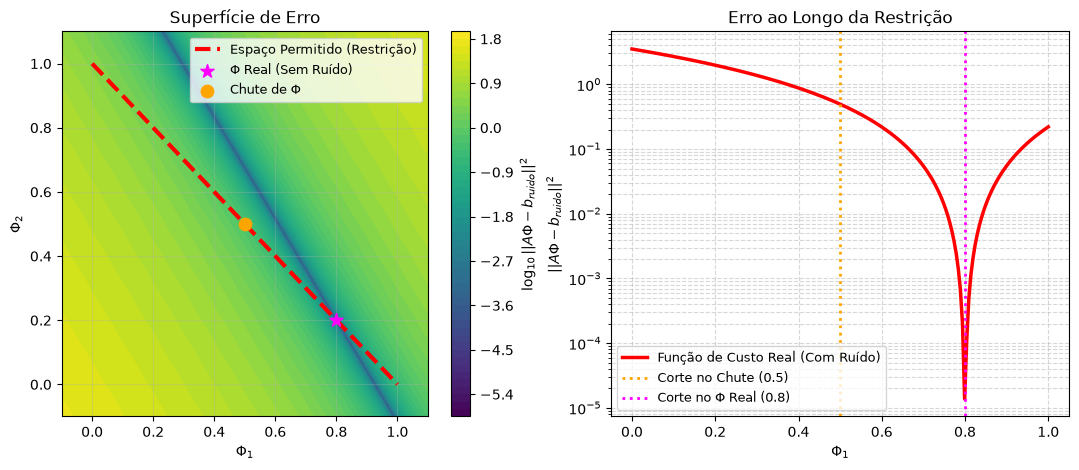

In [18]:
def visualizar_minimize():
    mtx, b_noisy, x0, phi = generate_data(
        gases_id=['co2_1', 'ar_1'],
        lambdas=[0.4, 0.8],
        phi=[0.8, 0.2],
        err=0.001
    )
    
    plot_mesh(
        A=mtx,
        b_noise=b_noisy,
        alfa=0,
        phi_real=phi,
        phi_chute=x0,
    )

visualizar_minimize()

Fazer histogramas

In [19]:
def plot_histogramas_simulacao(phis_sim, phi_true, gases_nomes, n_bins=20):
    """
    Plota histogramas da distribuição das frações molares simuladas.
    O layout é forçado a um formato de 2 colunas para melhor organização.
    """
    phis_sim = np.asarray(phis_sim)
    n_gases = len(gases_nomes)
    
    # Cálculo das dimensões do subplot (2 colunas)
    n_cols = 2
    n_rows = int(np.ceil(n_gases / n_cols))
    
    # Instanciação da figura com dimensões proporcionais
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
    
    # Achatamento da matriz de eixos para iteração linear segura
    if n_gases == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(n_gases):
        ax = axes[i]
        dados = phis_sim[:, i]
        
        # Estatísticas do conjunto simulado
        media = np.mean(dados)
        desvio_padrao = np.std(dados)

        print(f'{gases_nomes[i]} - Média: {media:.4f}, Desvio Padrão: {desvio_padrao:.4f}')
        
        # Histograma e marcadores
        ax.hist(dados, bins=n_bins, color='steelblue', edgecolor='black', 
                alpha=0.7, density=True, label='Simulação')
        
        ax.axvline(phi_true[i], color='red', linestyle='--', linewidth=2, 
                   label=f'Real: {phi_true[i]:.4f}')
        
        ax.axvline(media, color='green', linestyle=':', linewidth=2, 
                   label=f'Média: {media:.4f}')
        
        # Ajuste Normal
        ax.set_xlim(0, 1)
        xmin, xmax = ax.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = scipy.stats.norm.pdf(x, media, desvio_padrao)
        ax.plot(x, p, 'k', linewidth=1.5, alpha=0.6, label='Ajuste Normal')
        
        ax.set_title(f'{gases_nomes[i]}')
        ax.set_xlabel('Fração Molar $\\phi$')
        ax.set_ylabel('Densidade de Frequência')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        
    # Remoção de subplots não utilizados (caso o número de gases seja ímpar)
    for j in range(n_gases, len(axes)):
        fig.delaxes(axes[j])
        
    # Controlo do layout via objecto Figure (fig)
    fig.suptitle('Análise de Dispersão das Frações Molares para solução restrita'
                 , y=0.975, fontsize=14)
    fig.tight_layout()
    
    return fig

Percebi que o chute importa bastante aqui. Por padrão o algorimito chuta um $\Phi$ uniforme, isto é, assume que todos os gases tem a mesma fração molar, igual à $1/\text{nº de gases}$. Portanto, para um o exemplo de 4 gases, quando eu dou uma fração molar real cujo os valores são próximos de 0.25, o resultado parece convergir bem. Mas ao simular para uma fração molar diferente disso, os resultados se espalham. Abaixo está um caso em que os resultados parecem convergir

Gases: N2, O2, CO2, Ar
Numero de condição da matrix: 7.87e+09
N2 - Média: 0.0000, Desvio Padrão: 0.0000
O2 - Média: 0.0000, Desvio Padrão: 0.0000
CO2 - Média: 0.0000, Desvio Padrão: 0.0000
Ar - Média: 0.0000, Desvio Padrão: 0.0000


/home/troad/Repo/gas_refractometry_optimize/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2079: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/troad/Repo/gas_refractometry_optimize/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2079: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


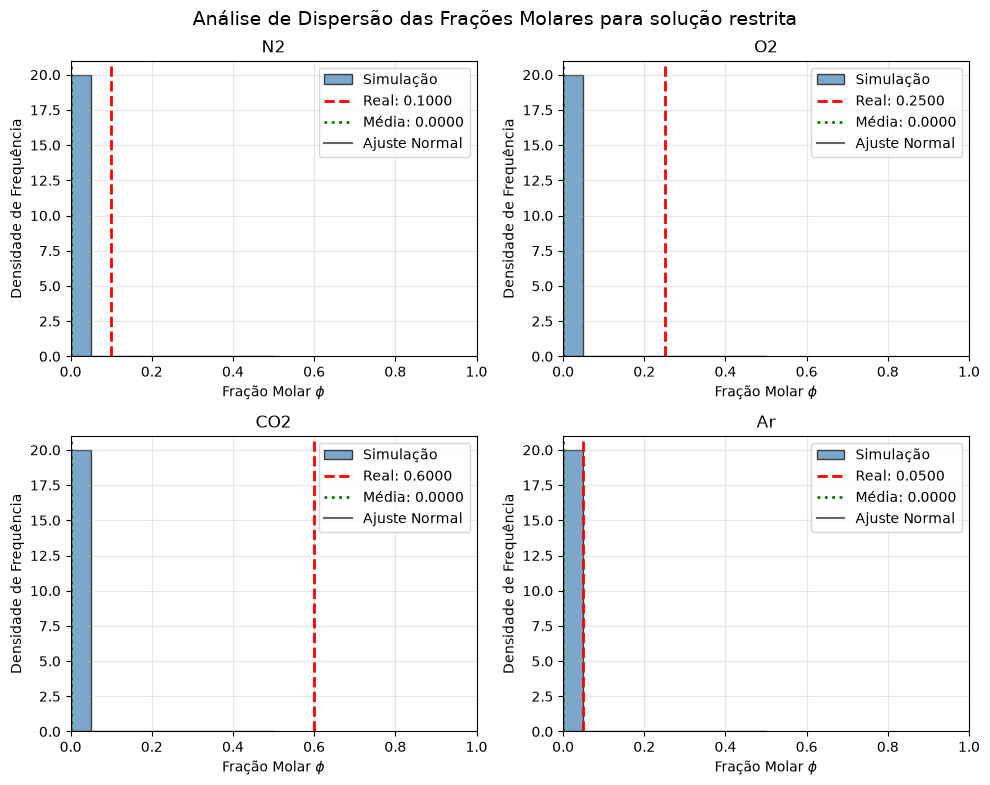

In [20]:
def analise_facil():
    gases_id=['n2_1', 'o2', 'co2_1', 'ar_1']
    gases_nomes = [gasopt.Gas(id).name for id in gases_id]

    # phi facil
    phi = [0.1, 0.25, 0.6, 0.05]

    # soluções com restrição
    phis_sim = solucao_restrita(
        gases_id=gases_id,
        lambdas=[0.74, 0.78 , 0.82, 0.86],
        phi=phi,
        erro=0.001,
        n=1000
    )

    plot_histogramas_simulacao(
        phis_sim = phis_sim, 
        phi_true = phi, 
        gases_nomes = gases_nomes)

analise_facil()

Gases: CO2, N2, Ar, O2
Numero de condição da matrix: 9.65e+06
CO2 - Média: 0.0000, Desvio Padrão: 0.0000
N2 - Média: 0.0000, Desvio Padrão: 0.0000
Ar - Média: 0.0000, Desvio Padrão: 0.0000
O2 - Média: 0.0000, Desvio Padrão: 0.0000


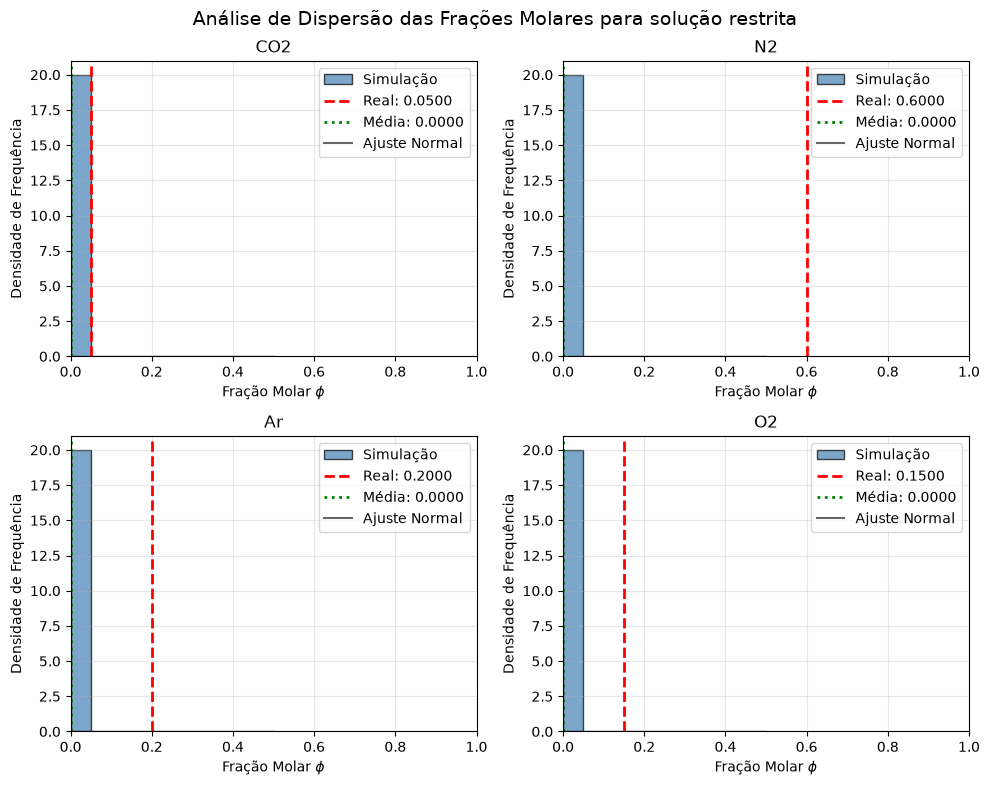

In [21]:
def analise_dificil():
    gases_id=['co2_1', 'n2_1', 'ar_1', 'o2']
    gases_nomes = [gasopt.Gas(id).name for id in gases_id]

    # phi facil
    phi = [0.05, 0.6, 0.2, 0.15]

    # soluções com restrição
    phis_sim = solucao_restrita(
        gases_id=['co2_1', 'n2_1', 'ar_1', 'o2'],
        lambdas=[0.4, 0.5, 0.6, 0.8],
        phi=phi,
        erro=0.0001,
        n=100
    )

    plot_histogramas_simulacao(
        phis_sim = phis_sim, 
        phi_true = phi, 
        gases_nomes = gases_nomes)

analise_dificil()

# Regularização Tikhonov

Do mesmo modo que foi feita solução restrita, será feito aqui. Porém queremos minimizar:

$$
||A\Phi - b_{ruido}||^2 + \alpha^2||\Phi||^2
$$

Porém é preciso encontrar o $\alpha$ que penaliza adequadamente os $\Phi$. Isso pode ser feito encontrando o canto da curva-L, formada pelas normas residuais e das normas de solução, ao varrer vários valores para $\alpha$

In [22]:
def plot_curva_L(alfas, normas_residuo, normas_solucao, peak_index=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    #normas_residuo, normas_solucao = np.log10(normas_residuo), np.log10(normas_solucao)

    # Desenha a linha de tendência da Curva L
    ax.plot(normas_residuo, normas_solucao, 'b-', linewidth=2, label='Caminho de Tikhonov')
    
    # Plota os pontos coloridos variando de acordo com o log10(alfa)
    sc = ax.scatter(normas_residuo, normas_solucao, c=np.log10(alfas), 
                    cmap='jet', s=35, zorder=5)
    
    # Configurações de eixos e labels em escala logarítmica
    ax.set_title("Curva L", fontsize=12)
    ax.set_xlabel(r"Norma do Resíduo: $\log_{10} ||A\Phi - b_{noise}||_2^2$", fontsize=10)
    ax.set_ylabel(r"Norma da Solução: $\log_{10} ||\Phi||_2^2$", fontsize=10)
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Barra de cores lateral para identificar visualmente o Alfa ideal
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(r"Parâmetro de Regularização $\log_{10}(\alpha)$")

    if peak_index != None:
        peak = normas_residuo[peak_index]
        ax.axvline(peak, linestyle='--', label=f"Máx. Curvatura: {peak}")
    
    ax.legend()


encontrando o parametro ótimo pela regularização de tikhonov

In [23]:
def setup_experiment(ids, l):
    operator = GasMix(ids=ids, wvlens=l, temp=273.15)

    mtx = operator.get_matrix()
    s_mtx = operator.get_sigma_matrix()

    return mtx, s_mtx

Optimal Alpha: 0.09540954763499963
Optimal Phi: [0.12630474 0.3038111  0.2765238  0.29336036]
Residual Norm: [-3.61134463 -3.61111315 -3.61092735 -3.608321   -3.59822376 -3.59646457
 -3.59583547 -3.58095505 -3.21378458 -2.00045812 -1.11411992 -0.83473801
 -0.78285301 -0.77465186 -0.77339313 -0.77320086 -0.77317151 -0.77316703
 -0.77316634 -0.77316624 -0.77316622 -0.77316622]
Solution Norm: [-0.11302798 -0.295663   -0.37036958 -0.42743235 -0.56280978 -0.56721443
 -0.56738376 -0.56779876 -0.57032999 -0.58167722 -0.59824934 -0.60189008
 -0.60205553 -0.60205989 -0.60205999 -0.60205999 -0.60205999 -0.60205999
 -0.60205999 -0.60205999 -0.60205999 -0.60205999]



(<gasopt.tikhonov.TikSolution at 0x78b92820e570>,
 array([0.1 , 0.25, 0.6 , 0.05]),
 ['co2_1', 'o2', 'n2_1', 'ar_2'])

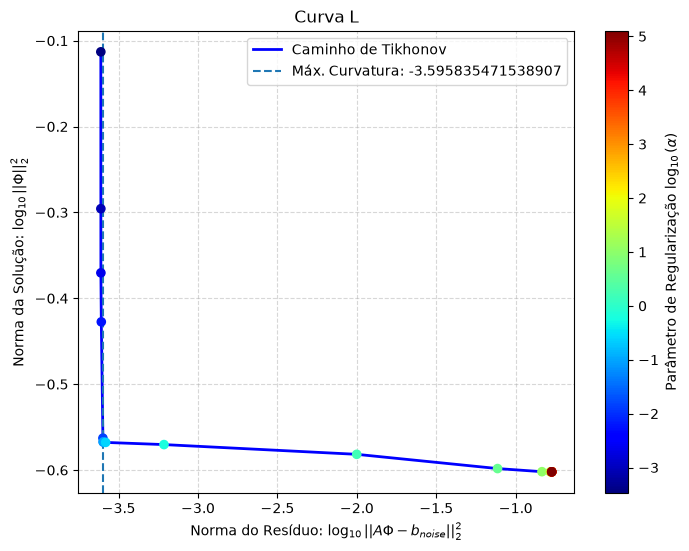

In [30]:
def tikhonov(plot=1):
    # constantes do experimento
    gases_id = ['co2_1', 'o2', 'n2_1', 'ar_2']
    lambdas = np.array([0.74, 0.78, 0.82, 0.86]) 
    phi_real = np.array([0.1, 0.25, 0.6, 0.05])
    erro = 0.01

    # operadores
    mtx, sigma_mtx = setup_experiment(gases_id, lambdas)
    b_real = mtx @ phi_real

    # simulação de resultado experimetal
    # refratividade observada
    b_obs = generate_noise(b_real, erro=erro)

    # criando um solucionador
    tik = TikhonovSolver(
        mtx=mtx,
        sigma_mtx=sigma_mtx,
        b_obs=b_obs,
        sigma_b=0
    )

    tik.alphas = np.logspace(-10, 10)

    # resolvendo o problema
    sol = tik.solve(log=True, method='spline')
    

    if plot == 0:
        return sol, phi_real, gases_id

    print(sol)

    plot_curva_L(
        alfas=sol.alphas,
        normas_residuo=sol.residual_norm,
        normas_solucao=sol.solution_norm,
        peak_index = sol.opt_index
    )

    return sol, phi_real, gases_id

tikhonov()

verificando os resultado para o parametro ótimo encontrado

In [25]:
def iter_solucao_tikhonov(n):
    phis = np.zeros([n, 4])
    for i in range(n):
        sol, phi_real, ids = tikhonov(plot=0)

        phis[i] = sol.opt_phi
    
    return phis, phi_real, ids

f = plot_histogramas_simulacao(*iter_solucao_tikhonov(400), n_bins=40)


KeyboardInterrupt: 

Entregaveis tihkonov

In [ ]:
def plot_mse_tik(alfas, mse):
    fig, ax = plt.subplots()

    ax.scatter(alfas, mse, s=10, marker='s',
               label='MSE de $\\Phi_{\\alpha}$')

    ax.set_title('Erro Quadrático Médio (MSE)')
    ax.set_ylabel('MSE')
    ax.set_xlabel('$\\alpha$')
    ax.set_xscale('log')
    ax.grid(1)
    ax.set_axisbelow(True)
    ax.legend()
    

In [ ]:
def mse(x, x_real):
    return np.sum((x - x_real)**2) / len(x)

In [ ]:
def analise_tikhonov():
    tik = gasopt.TikhonovSolver(
        gases_id=['co2_1', 'ar_1', 'n2_1', 'o2'],
        lambdas=[0.4, 0.5, 0.6, 0.8],
        phi=[0.1, 0.2, 0.4, 0.3],
        erro=0.01,
        temp=273.15,
    )

    # dados
    tik.alphas = np.logspace(-5, 5)
    phi_real = tik.phi
    x0 = np.ones(len(phi_real))/len(phi_real)
    b = tik.A @ tik.phi
    
    # info analise
    n_sample = 200
    mse_array = np.zeros(len(tik.alphas))

    # varre os alfas
    for idx, alfa in enumerate(tik.alphas):
        
        # calcula n phis
        phis_sim = np.zeros((n_sample, len(phi_real)))
        for n in range(n_sample):
            b_noisy = gasopt.generate_noise(b, erro=tik.erro)
            phis_sim[n] = tik.minimize_constrain(tik.A, b_noisy, alfa, x0)

        # calcula o mse
        erro = mse(phis_sim, phi_real)
        mse_array[idx] = erro

    return mse_array, tik.alphas

#mse_tik, alfas = analise_tikhonov()

In [ ]:
#plot_mse_tik(alfas, mse_tik)